# Arabic Sentiment Analysis

In [148]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
train = pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/test.csv')
sample_submission = pd.read_csv('/kaggle/input/competitions/arabic-sentiment-ai-challenge/sample_submission.csv')

### Explore the Dataset

In [150]:
train.head()

,Review_ID,Hotel_Name,Sentiment,User_Type,Room_Type,Nights,Review
0,3,فندق 72,1,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...
1,16,فندق 72,1,زوج,-,أقمت ليلتين,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...
2,20,فندق 72,0,زوج,غرفة قياسية مزدوجة,أقمت ليلة واحدة,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...
3,25,فندق 72,1,زوج,غرفة ديلوكس مزدوجة أو توأم,أقمت ليلة واحدة,“جيدجداً”. الافطار جيد والسرير ممتاز ومريح واط...
4,26,فندق 72,1,مسافر منفرد,-,أقمت ليلتين,“فندق ممتاز”. الاثاث، النظافه.


In [151]:
train.shape

(84443, 7)

In [152]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84443 entries, 0 to 84442
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Review_ID   84443 non-null  int64 
 1   Hotel_Name  84443 non-null  object
 2   Sentiment   84443 non-null  int64 
 3   User_Type   84443 non-null  object
 4   Room_Type   84443 non-null  object
 5   Nights      84443 non-null  object
 6   Review      84443 non-null  object
dtypes: int64(2), object(5)
memory usage: 4.5+ MB


In [153]:
train['Sentiment'].value_counts(normalize=True)

Sentiment
0    0.500468
1    0.499532
Name: proportion, dtype: float64

In [154]:
train.nunique()

Review_ID     84443
Hotel_Name     1173
Sentiment         2
User_Type         6
Room_Type      1015
Nights           31
Review        83229
dtype: int64

In [155]:
train['User_Type'].value_counts()

User_Type
أسرة                           35105
زوج                            24647
مسافر منفرد                    13914
-                              10771
استوديو كلاسيكي - أسرة توأم        5
جناح بغرفتي نوم أسرة توأم          1
Name: count, dtype: int64

In [156]:
train['Room_Type'].value_counts().head(20)

Room_Type
-                             25030
غرفة قياسية مزدوجة             3678
غرفة مزدوجة                    3313
شقة من غرفة نوم واحدة          2643
غرفة توأم                      2470
غرفة قياسية                    2356
غرفة ديلوكس                    2005
غرفة ثلاثية                    1915
غرفة قياسية توأم               1859
غرفة قياسية مزدوجة أو توأم     1609
غرفة سوبيريور مزدوجة           1586
غرفة ديلوكس مزدوجة             1356
غرفة كلاسيكية كينغ             1211
غرفة رباعية                    1140
جناح من غرفة نوم واحدة          870
غرفة قياسية ثلاثية              838
غرفة ديلوكس مزدوجة أو توأم      822
غرفة ديلوكس كينغ                818
غرفة سوبيريور كينغ              755
غرفة مزدوجة أو توأم             745
Name: count, dtype: int64

In [157]:
train['Nights'].value_counts().head(20)

Nights
أقمت ليلة واحدة    35622
أقمت ليلتين        21959
أقمت 3 ليالي       11639
أقمت 4 ليالي        5985
أقمت 5 ليالي        3837
أقمت 6 ليالي        1858
أقمت 7 ليالي        1475
-                    738
أقمت 8 ليالي         532
أقمت 9 ليالي         265
أقمت 10 ليالي        211
أقمت 11 ليلة          94
أقمت 12 ليلة          70
أقمت 13 ليلة          49
أقمت 14 ليلة          34
أقمت 15 ليلة          24
أقمت 16 ليلة          15
أقمت 18 ليلة           7
أقمت 20 ليلة           6
أقمت 30 ليلة           5
Name: count, dtype: int64

In [158]:
train['Review'].str.len().describe()

count    84443.000000
mean       137.415369
std        137.781849
min          6.000000
25%         54.000000
50%         97.000000
75%        172.000000
max       3365.000000
Name: Review, dtype: float64

In [159]:
train['Review'].str.split().str.len().describe()

count    84443.000000
mean        24.012932
std         24.694019
min          2.000000
25%          9.000000
50%         17.000000
75%         30.000000
max        614.000000
Name: Review, dtype: float64

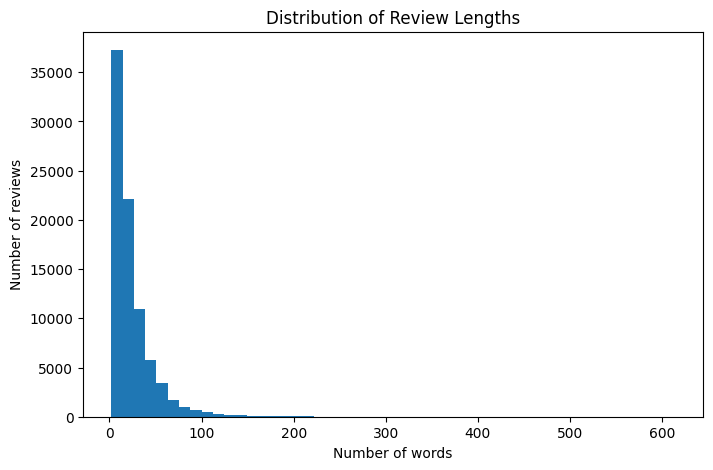

In [160]:
plt.figure(figsize=(8, 5))
plt.hist(train['Review'].str.split().str.len(), bins=50)
plt.xlabel('Number of words')
plt.ylabel('Number of reviews')
plt.title('Distribution of Review Lengths')
plt.show()

In [161]:
train[['Review', 'Sentiment']].sample(10)

,Review,Sentiment
82056,“زبالة حقير”. نت فقط. اعتقد لو اني في دولة اخر...,0
639,ضعيف. السعر تمام. وجود البق في الغرفة,0
1788,مخيب للأمل. الموقع قريب من محطة شرف دي دي المت...,0
29674,“رائع”. بصراحه قمه في الراحه وانا اول مره اسكن...,1
4160,مخيب للأمل. تعامل الاستقبال. النظافة,0
3718,“اسوأ فندق فى العالم”. . سارقين ونصابين .. اله...,0
70113,“يجب يكون العزاب بطابق خاص ويضع حمايه علي الن...,0
34955,مخيب للأمل. المكان. يوجد ريحه كريهه في الدور ١...,0
34309,رائع. موقع الفندق على شارع الشيخ زايد اطلالة ا...,1
56779,“تجربة غير مريحة”. بهو الفندق (اللوبي) قاعات ا...,0


In [162]:
train['Review'].duplicated().sum()

np.int64(1214)

In [163]:
train.groupby('Review')['Sentiment'].nunique().value_counts()

Sentiment
1    83229
Name: count, dtype: int64

In [164]:
pd.crosstab(train['Nights'], train['Sentiment'])

Sentiment,0,1
Nights,,
-,527,211
أقمت 10 ليالي,91,120
أقمت 11 ليلة,45,49
أقمت 12 ليلة,32,38
أقمت 13 ليلة,26,23
أقمت 14 ليلة,19,15
أقمت 15 ليلة,10,14
أقمت 16 ليلة,8,7
أقمت 17 ليلة,2,1


In [165]:
train['Review'].head(10)

0    استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...
1    استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...
2    “استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...
3    “جيدجداً”. الافطار جيد والسرير ممتاز ومريح واط...
4                      “فندق ممتاز”. الاثاث، النظافه. 
5    “الراحة و الهدوء”. مكان مناسب ومريح  انصح به خ...
6    استثنائي. المكان روعه تحديدا الغرف المطله على ...
7    “إقامتي في فندق 72 الشارقة”. موقع الفندق ممتاز...
8                 “فندق الراحه”. قربه من الاسواق. لاشي
9    “أسرة اماراتية.”. فندق مبنى على الطراز الحديث،...
Name: Review, dtype: object

### Text Preprocessing

In [166]:
import re
def clean_text(text):
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['Clean_Review'] = train['Review'].apply(clean_text)
test['Clean_Review'] = test['Review'].apply(clean_text)
train[['Review', 'Clean_Review']].head()

,Review,Clean_Review
0,استثنائي. سهولة إنهاء المعاملة في الاستقبال. ل...,استثنائي سهولة إنهاء المعاملة في الاستقبال لاشيئ
1,استثنائي. انصح بأختيار الاسويت و بالاخص غرفه ر...,استثنائي انصح بأختيار الاسويت و بالاخص غرفه رق...
2,“استغرب تقييم الفندق كخمس نجوم”. لا شي. يستحق ...,استغرب تقييم الفندق كخمس نجوم لا شي يستحق نجمه
3,“جيدجداً”. الافطار جيد والسرير ممتاز ومريح واط...,جيدجداً الافطار جيد والسرير ممتاز ومريح واطلال...
4,“فندق ممتاز”. الاثاث، النظافه.,فندق ممتاز الاثاث، النظافه


### Train / Validation Split

In [167]:
from sklearn.model_selection import train_test_split

x = train['Clean_Review']
y = train['Sentiment']
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42
)

print(x_train.shape)
print(x_val.shape)

(67554,)
(16889,)


### Traditional Machine Learning Models

In [168]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)
x_train_tfidf = tfidf.fit_transform(x_train)
x_val_tfidf = tfidf.transform(x_val)

print(x_train_tfidf.shape)
print(x_val_tfidf.shape)

(67554, 10000)
(16889, 10000)


In [169]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_tfidf, y_train)

LogisticRegression()

In [170]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(x_val_tfidf)
print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.929539937237255
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      8349
           1       0.93      0.94      0.93      8540

    accuracy                           0.93     16889
   macro avg       0.93      0.93      0.93     16889
weighted avg       0.93      0.93      0.93     16889



In [171]:
tfidf_bigram_20k = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

x_train_bigram_20k = tfidf_bigram_20k.fit_transform(x_train)
x_val_bigram_20k = tfidf_bigram_20k.transform(x_val)


In [172]:
model_bigram_20k = LogisticRegression()

model_bigram_20k.fit(x_train_bigram_20k, y_train)

y_pred_bigram_20k = model_bigram_20k.predict(x_val_bigram_20k)

print("Accuracy:", accuracy_score(y_val, y_pred_bigram_20k))
print(classification_report(y_val, y_pred_bigram_20k))

Accuracy: 0.937651725975487
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      8349
           1       0.93      0.94      0.94      8540

    accuracy                           0.94     16889
   macro avg       0.94      0.94      0.94     16889
weighted avg       0.94      0.94      0.94     16889



In [173]:
model_svm = LinearSVC()

model_svm.fit(x_train_bigram_20k, y_train)

y_pred_svm = model_svm.predict(x_val_bigram_20k)

print("Accuracy:", accuracy_score(y_val, y_pred_svm))
print(classification_report(y_val, y_pred_svm))

Accuracy: 0.9299544081946829
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      8349
           1       0.93      0.93      0.93      8540

    accuracy                           0.93     16889
   macro avg       0.93      0.93      0.93     16889
weighted avg       0.93      0.93      0.93     16889



In [174]:
from sklearn.naive_bayes import MultinomialNB

model_nb = MultinomialNB()
model_nb.fit(x_train_bigram_20k, y_train)

y_pred_nb = model_nb.predict(x_val_bigram_20k)

print("Accuracy:", accuracy_score(y_val, y_pred_nb))
print(classification_report(y_val, y_pred_nb))

Accuracy: 0.9084019184084315
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      8349
           1       0.92      0.90      0.91      8540

    accuracy                           0.91     16889
   macro avg       0.91      0.91      0.91     16889
weighted avg       0.91      0.91      0.91     16889



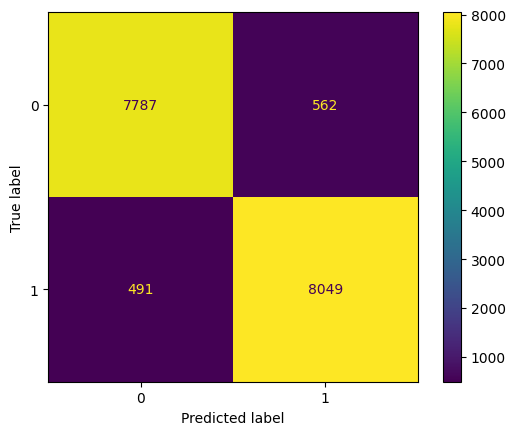

In [175]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred_bigram_20k)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### Prepare Text for Deep Learning

In [178]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_val_seq = tokenizer.texts_to_sequences(x_val)

In [179]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train_pad = pad_sequences(x_train_seq, maxlen=100, padding='post')
x_val_pad = pad_sequences(x_val_seq, maxlen=100, padding='post')

print(x_train_pad.shape)
print(x_val_pad.shape)

(67554, 100)
(16889, 100)


## RNN Model

In [180]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model_rnn = Sequential([
    Embedding(input_dim=10000, output_dim=64),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [181]:
history_rnn = model_rnn.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 33s 29ms/step - accuracy: 0.8900 - loss: 0.2980 - val_accuracy: 0.9109 - val_loss: 0.2386
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 32s 30ms/step - accuracy: 0.9299 - loss: 0.2008 - val_accuracy: 0.9217 - val_loss: 0.2115
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.9392 - loss: 0.1783 - val_accuracy: 0.9159 - val_loss: 0.2446
Epoch 4/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.9323 - loss: 0.1961 - val_accuracy: 0.8352 - val_loss: 0.4012
Epoch 5/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 30s 29ms/step - accuracy: 0.8448 - loss: 0.3667 - val_accuracy: 0.7886 - val_loss: 0.4931


In [182]:
y_pred_rnn = (model_rnn.predict(x_val_pad) > 0.5).astype(int).ravel()

print("RNN Accuracy:", accuracy_score(y_val, y_pred_rnn))
print(classification_report(y_val, y_pred_rnn))

528/528 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
RNN Accuracy: 0.7885606015749896
              precision    recall  f1-score   support

           0       0.79      0.77      0.78      8349
           1       0.78      0.80      0.79      8540

    accuracy                           0.79     16889
   macro avg       0.79      0.79      0.79     16889
weighted avg       0.79      0.79      0.79     16889



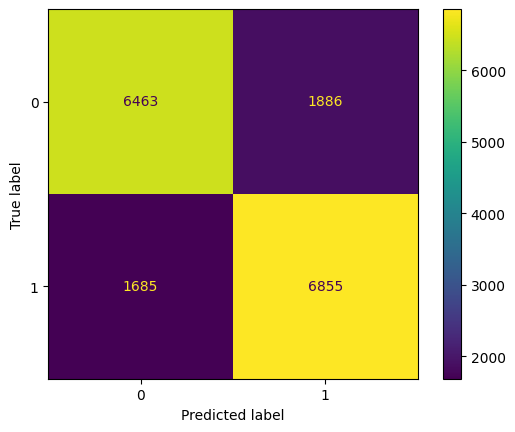

In [183]:
cm_rnn = confusion_matrix(y_val, y_pred_rnn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rnn)
disp.plot()
plt.show()

## LSTM Model

In [184]:
from tensorflow.keras.layers import LSTM
model_lstm = Sequential([
    Embedding(input_dim=10000, output_dim=64),
    LSTM(64),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [185]:
history_lstm = model_lstm.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 71s 65ms/step - accuracy: 0.5007 - loss: 0.6937 - val_accuracy: 0.4943 - val_loss: 0.6948
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 69s 65ms/step - accuracy: 0.6338 - loss: 0.5938 - val_accuracy: 0.8511 - val_loss: 0.4178
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 68s 64ms/step - accuracy: 0.8424 - loss: 0.4201 - val_accuracy: 0.8930 - val_loss: 0.2837
Epoch 4/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 68s 64ms/step - accuracy: 0.9310 - loss: 0.1924 - val_accuracy: 0.9435 - val_loss: 0.1584
Epoch 5/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 69s 65ms/step - accuracy: 0.9564 - loss: 0.1306 - val_accuracy: 0.9422 - val_loss: 0.1580


In [186]:
y_pred_lstm = model_lstm.predict(x_val_pad)
y_pred_lstm = (y_pred_lstm > 0.5).astype(int)
y_pred_lstm = y_pred_lstm.ravel()
print("LSTM Accuracy:", accuracy_score(y_val, y_pred_lstm))
print(classification_report(y_val, y_pred_lstm))

528/528 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step
LSTM Accuracy: 0.9422109065071941
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      8349
           1       0.94      0.95      0.94      8540

    accuracy                           0.94     16889
   macro avg       0.94      0.94      0.94     16889
weighted avg       0.94      0.94      0.94     16889



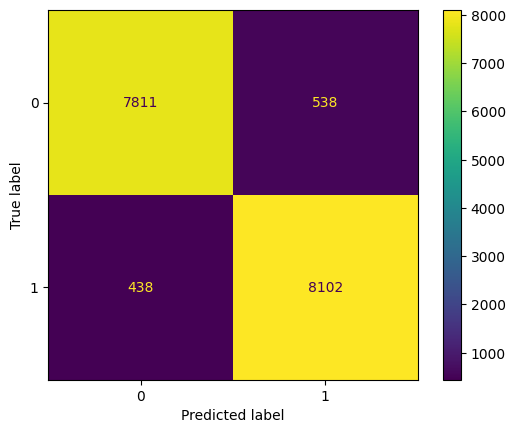

In [187]:
cm_lstm = confusion_matrix(y_val, y_pred_lstm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)
disp.plot()
plt.show()

## GRU Model

In [188]:
from tensorflow.keras.layers import GRU
model_gru = Sequential([
    Embedding(input_dim=10000, output_dim=64),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [189]:
history_gru = model_gru.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 83s 75ms/step - accuracy: 0.5125 - loss: 0.6868 - val_accuracy: 0.8750 - val_loss: 0.3062
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.9385 - loss: 0.1702 - val_accuracy: 0.9442 - val_loss: 0.1540
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.9592 - loss: 0.1220 - val_accuracy: 0.9438 - val_loss: 0.1544
Epoch 4/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.9694 - loss: 0.0948 - val_accuracy: 0.9406 - val_loss: 0.1659
Epoch 5/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 79s 75ms/step - accuracy: 0.9771 - loss: 0.0741 - val_accuracy: 0.9375 - val_loss: 0.2064


In [190]:
y_pred_gru = model_gru.predict(x_val_pad)

y_pred_gru = (y_pred_gru > 0.5).astype(int)
y_pred_gru = y_pred_gru.ravel()

print("GRU Accuracy:", accuracy_score(y_val, y_pred_gru))
print(classification_report(y_val, y_pred_gru))

528/528 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step
GRU Accuracy: 0.9374740955651607
              precision    recall  f1-score   support

           0       0.94      0.93      0.94      8349
           1       0.93      0.95      0.94      8540

    accuracy                           0.94     16889
   macro avg       0.94      0.94      0.94     16889
weighted avg       0.94      0.94      0.94     16889



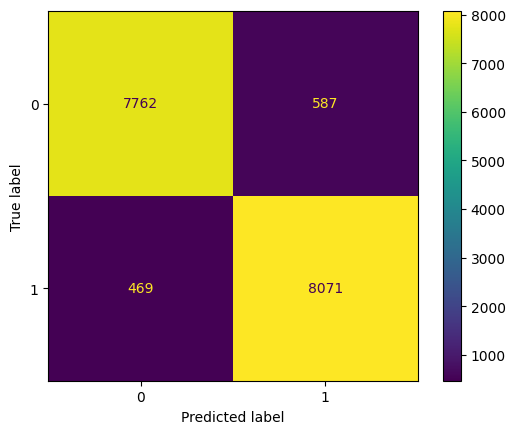

In [191]:
cm_gru = confusion_matrix(y_val, y_pred_gru)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_gru)
disp.plot()
plt.show()

## Transformer Model

In [192]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, MultiHeadAttention
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense

inputs = Input(shape=(100,))

x = Embedding(input_dim=10000, output_dim=64)(inputs)

x = MultiHeadAttention(
    num_heads=2,
    key_dim=32
)(x, x)

x = GlobalAveragePooling1D()(x)

x = Dense(32, activation='relu')(x)

outputs = Dense(1, activation='sigmoid')(x)

model_transformer = Model(inputs, outputs)

model_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [193]:
history_transformer = model_transformer.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 70s 65ms/step - accuracy: 0.8863 - loss: 0.2593 - val_accuracy: 0.9221 - val_loss: 0.2020
Epoch 2/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 68s 65ms/step - accuracy: 0.9415 - loss: 0.1674 - val_accuracy: 0.9262 - val_loss: 0.1919
Epoch 3/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 68s 64ms/step - accuracy: 0.9496 - loss: 0.1446 - val_accuracy: 0.9239 - val_loss: 0.1964
Epoch 4/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 68s 64ms/step - accuracy: 0.9553 - loss: 0.1275 - val_accuracy: 0.9225 - val_loss: 0.2167
Epoch 5/5
1056/1056 ━━━━━━━━━━━━━━━━━━━━ 68s 65ms/step - accuracy: 0.9598 - loss: 0.1107 - val_accuracy: 0.9201 - val_loss: 0.2774


In [194]:
y_pred_transformer = model_transformer.predict(x_val_pad)

y_pred_transformer = (y_pred_transformer > 0.5).astype(int)
y_pred_transformer = y_pred_transformer.ravel()

print("Transformer Accuracy:", accuracy_score(y_val, y_pred_transformer))
print(classification_report(y_val, y_pred_transformer))

528/528 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step
Transformer Accuracy: 0.9201255254899638
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      8349
           1       0.91      0.93      0.92      8540

    accuracy                           0.92     16889
   macro avg       0.92      0.92      0.92     16889
weighted avg       0.92      0.92      0.92     16889



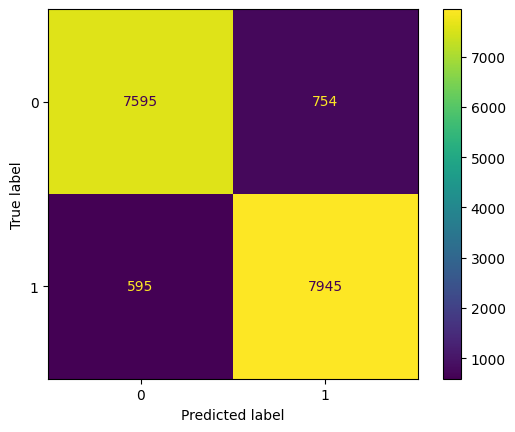

In [195]:
cm_transformer = confusion_matrix(y_val, y_pred_transformer)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_transformer)
disp.plot()
plt.show()

### Comparison

In [196]:
results = {
    "RNN": accuracy_score(y_val, y_pred_rnn),
    "LSTM": accuracy_score(y_val, y_pred_lstm),
    "GRU": accuracy_score(y_val, y_pred_gru),
    "Transformer": accuracy_score(y_val, y_pred_transformer)
}

for model, accuracy in results.items():
    print(model, ":", accuracy)

RNN : 0.7885606015749896
LSTM : 0.9422109065071941
GRU : 0.9374740955651607
Transformer : 0.9201255254899638


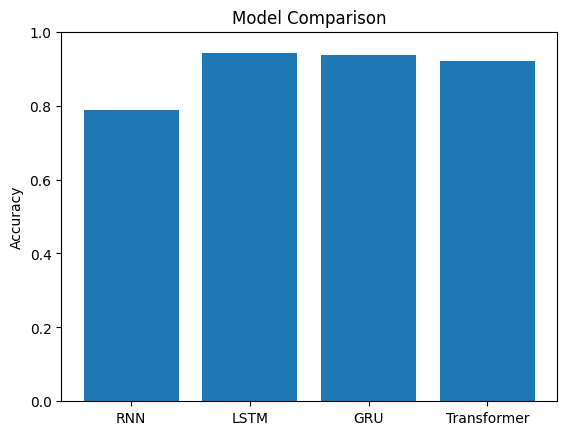

In [197]:
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0, 1)
plt.show()

### Error Analysis

In [198]:
errors = train.loc[x_val.index].copy()
errors['Predicted'] = y_pred_lstm
errors = errors[errors['Sentiment'] != errors['Predicted']]

errors[['Review', 'Sentiment', 'Predicted']].head(10)

,Review,Sentiment,Predicted
41172,ممتاز. الفندق على بعد خطوات من مول الامارات - ...,1,0
55496,“5 من ١٠”. . تعامل عمالة الفندق اصحاب فترة الليل,1,0
49175,“مكان جميل خدمه تعبانه استقبال فاشل”. الطاقم. ...,0,1
66166,“مخيب للآمال”. النظافة وقربه من بعض الأماكن ال...,0,1
27858,“يستحق فوق الممتاز وبمشئة الله عندما اكون في م...,0,1
46549,“سرعة في اتمام السكن ”. . المكيف توجدبه ريحه نتنه,0,1
32231,“جيد ولا باس به”. الفرش والاثاث والموقع توفر ا...,0,1
3502,مخيب للأمل. الموقع فقط لاغير. لن أكون ظالمة لل...,0,1
38421,“ادفع تمشى وتدلع يسلخوك مافى مشكله بس كل ما ان...,0,1
8898,“راس الخيمة”. كل شي. السعر في الحجز لم يحدد سو...,1,0


## Inference and Submission

The LSTM achieved the best validation accuracy among the tested neural architectures, so we use it to predict the unseen test reviews.

In [199]:
x_test_seq = tokenizer.texts_to_sequences(test['Clean_Review'])

x_test_pad = pad_sequences(
    x_test_seq,
    maxlen=100,
    padding='post'
)

test_predictions_lstm = (
    model_lstm.predict(x_test_pad) > 0.5
).astype(int).ravel()

submission = pd.DataFrame({
    'Review_ID': test['Review_ID'],
    'Sentiment': test_predictions_lstm
})

submission.to_csv('submission.csv', index=False)

print(submission.head())
print(submission.shape)

664/664 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step
   Review_ID  Sentiment
0     241096          1
1     397912          0
2     323390          0
3     365977          1
4     321051          1
(21222, 2)
